# Concrete Compressive Strength Predictor


A data model that predicts the compressive strength of a concrete mixture from its raw
material composition, using the UCI Concrete Compressive Strength dataset.

## Background

The compressive strength of concrete determines its quality. Strength is normally measured
with a standard crushing test on a concrete cylinder, which requires building small cylinders
with different combinations of raw materials and testing them for strength. The recommended
wait time before testing a cylinder is 28 days, which makes the traditional approach slow and
labor intensive.

A predictive data model can shortcut this process. Because compressive strength tests have
been run many times already, there is enough real world data available to train a model that
estimates strength directly from a mixture's composition, without waiting on a physical cure
and crush cycle.

## Objectives

- Review background literature on concrete mixture design and the value of a predictive
  approach.
- Analyze an existing concrete compressive strength database and build a data model to
  predict compressive strength.
- Build an interface that lets a user enter a concrete mixture and get back an estimated
  strength.
- Build a way to add new observations to the underlying database and retrain the model.


## Literature Research

**Challenges of concrete mixture design**

1. **Material variability.** Raw materials such as cement, aggregates, and admixtures vary in
   their properties from batch to batch.
2. **Environmental considerations.** Sustainable mix designs that use recycled materials and
   aim for a reduced carbon footprint add complexity to the design process.
3. **Cost.** Hitting the desired mix properties within a budget requires optimizing material
   usage and minimizing waste.

**Why compressive strength matters**

1. **Structural integrity.** Compressive strength indicates a mix's ability to withstand loads
   and pressures, which is central to the safety of a structure.
2. **Performance prediction.** Testing strength gives engineers a reliable way to predict how a
   mix will perform under different conditions.
3. **Durability.** Higher compressive strength tends to correlate with better resistance to
   things like freeze-thaw cycles and chemical attack.

**Why a data model helps**

1. **Precision.** A data model can account for many factors and their interactions at once,
   which tends to produce more accurate strength estimates than simple heuristics.
2. **Customization.** Models can be tuned to specific mix designs and environmental
   conditions.
3. **Continuous improvement.** A model can be retrained as new observations come in, so it
   keeps improving instead of staying fixed.

**References**

- I-Cheng Yeh, "Modeling of strength of high performance concrete using artificial neural
  networks," *Cement and Concrete Research*, Vol. 28, No. 12, pp. 1797-1808 (1998).
- UCI Machine Learning Repository, [Concrete Compressive Strength Data
  Set](https://archive.ics.uci.edu/ml/datasets/Concrete+Compressive+Strength).
- Laskar, A. I. (2011). Mix design of high-performance concrete. *Materials Research*, 14(4),
  429-433.
- Kabir, A., Hasan, M. M., & Miah, K. (2013). Strength prediction model for concrete. *ACEE
  Int. J. on Civil and Environmental Engineering*, 2(1).


## Database Acquisition

The dataset used here is the UCI **Concrete Compressive Strength** dataset. Download
`Concrete_Data.xls` from the UCI repository and place it in the `data/` folder before running
this notebook:

<https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls>


In [1]:
## importing all required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf


In [2]:
## reading the data file
data = pd.read_excel("data/Concrete_Data.xls")


To understand the data and check for any missing values, let's print and inspect it first.

In [3]:
data.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


## Exploratory Data Analysis

The original column headers are long and awkward to work with (they include units and
component numbers), so the next step renames them to short, readable names.

In [4]:
## renaming the columns to simpler names
new_names = ["Cement", "BlastFurnaceSlag", "FlyAsh", "Water", "Superplasticizer",
             "CoarseAggregate", "FineAggregate", "Age", "CC_Strength"]
current_names = list(data.columns)
mapper = {current_names[i]: new_names[i] for i in range(len(current_names))}
data = data.rename(columns=mapper)
data.head()


,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,CC_Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


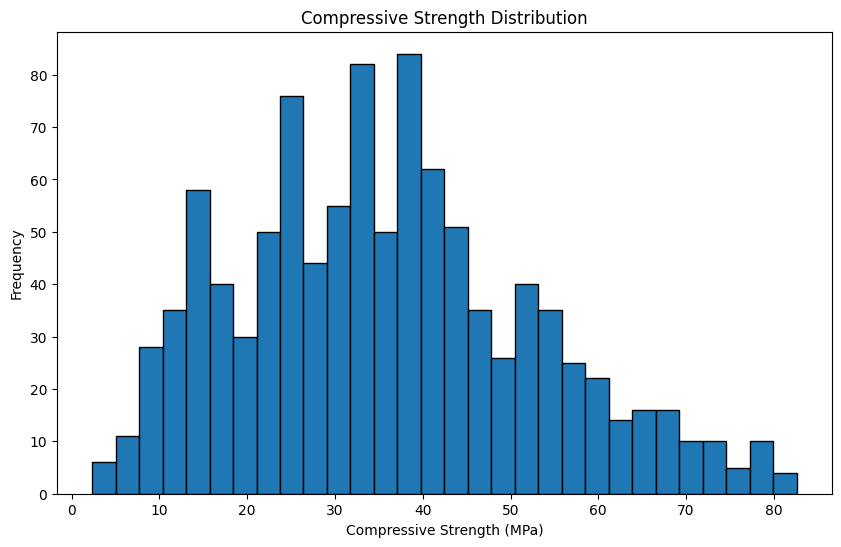

In [5]:
# Plot the compressive strength distribution
plt.figure(figsize=(10, 6))
plt.hist(data['CC_Strength'], bins=30, edgecolor='black')
plt.xlabel('Compressive Strength (MPa)')
plt.ylabel('Frequency')
plt.title('Compressive Strength Distribution')
plt.show()


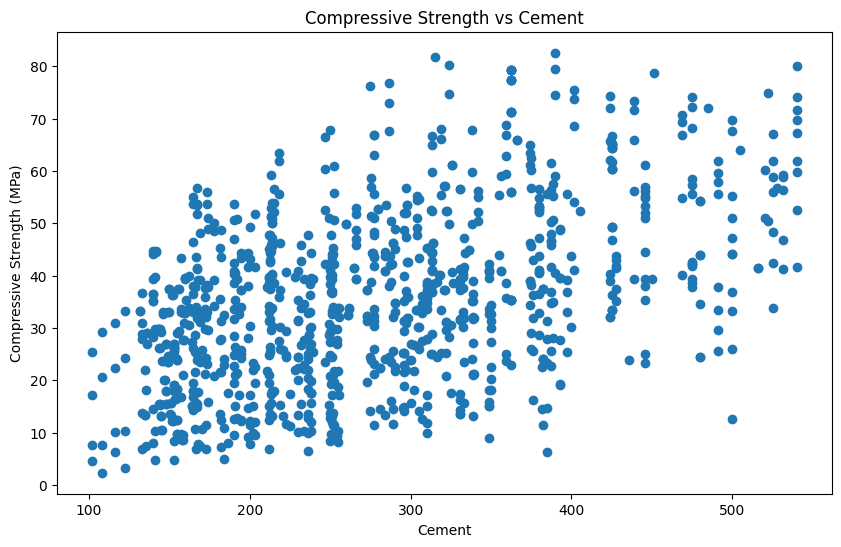

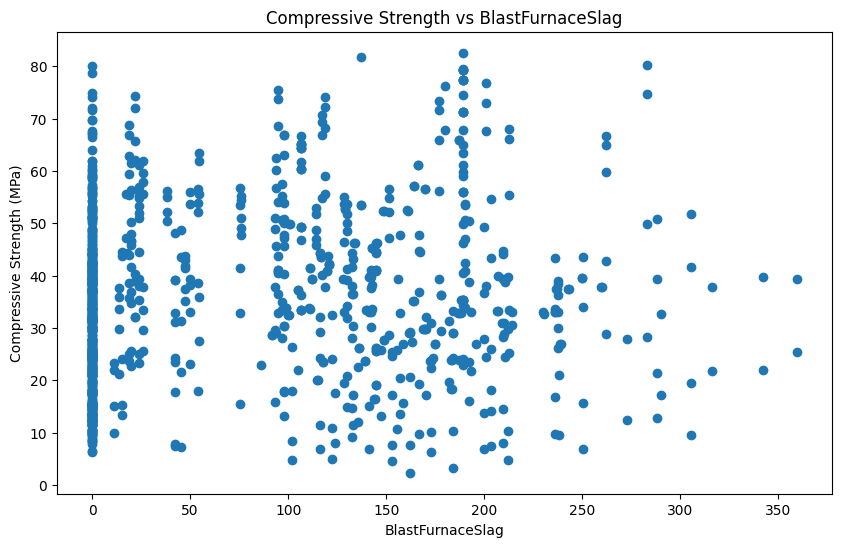

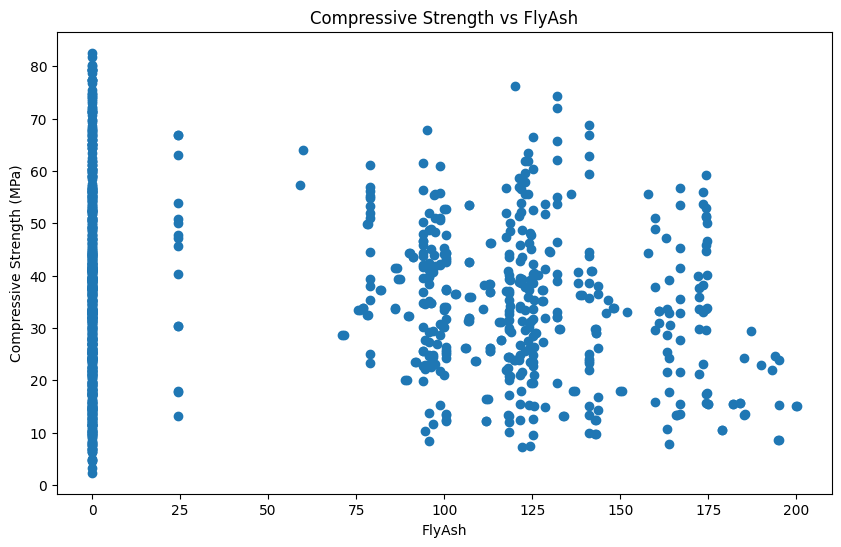

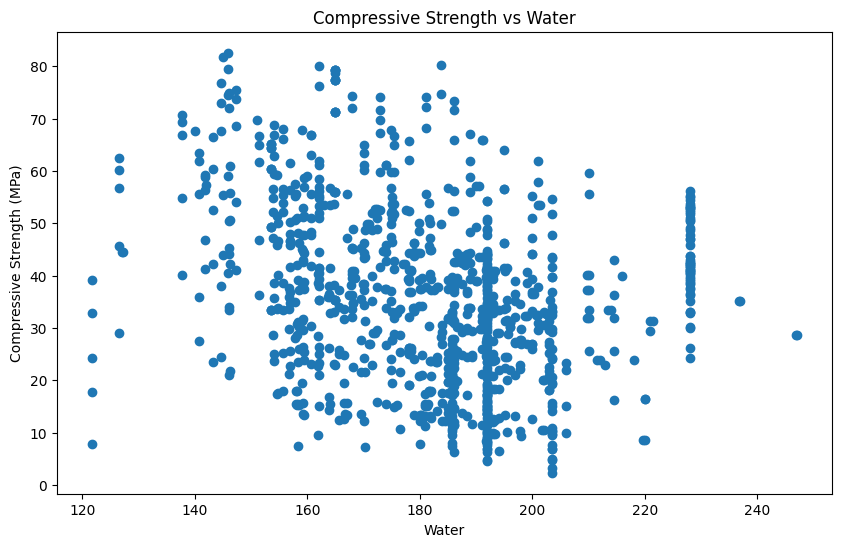

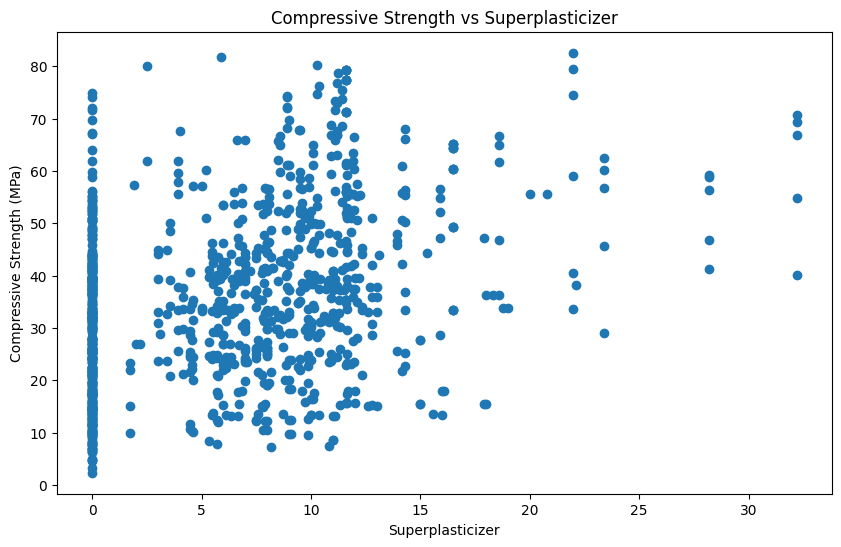

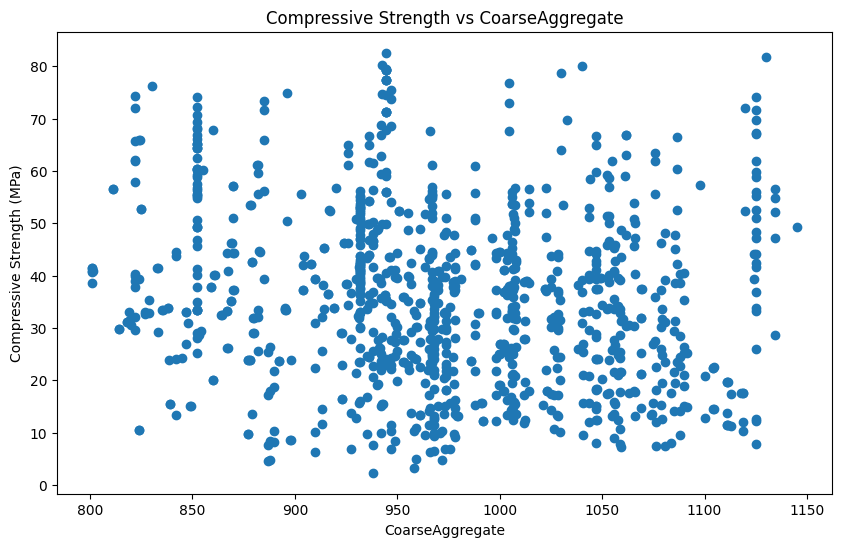

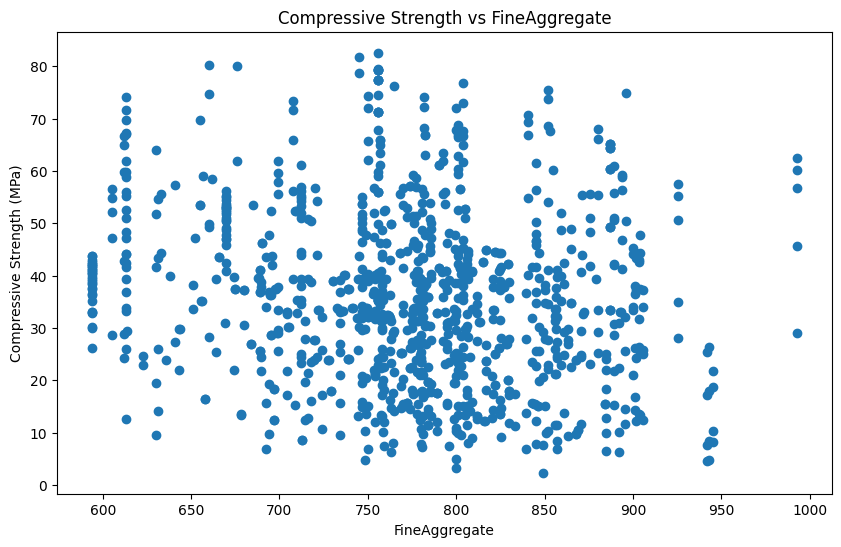

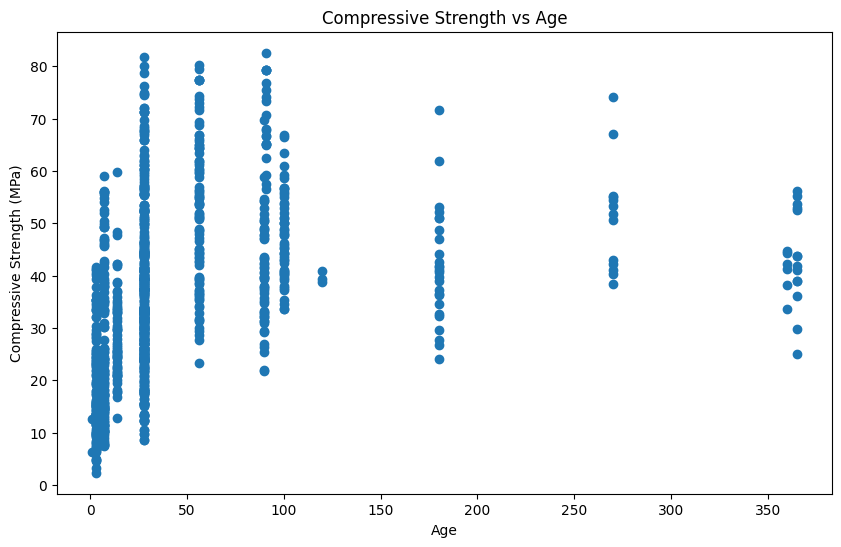

In [6]:
# Plot strength against each raw material / feature
for feature in ["Cement", "BlastFurnaceSlag", "FlyAsh", "Water", "Superplasticizer",
                "CoarseAggregate", "FineAggregate", "Age"]:
    plt.figure(figsize=(10, 6))
    plt.scatter(data[feature], data['CC_Strength'])
    plt.xlabel(feature)
    plt.ylabel('Compressive Strength (MPa)')
    plt.title(f'Compressive Strength vs {feature}')
    plt.show()


## Model Building

A linear regression model is trained on the eight mixture features to predict compressive
strength.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Separate features and target variable
X = data.drop(columns=['CC_Strength'])
y = data['CC_Strength']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the linear regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Make predictions on the test set
y_pred = lr.predict(X_test)

# Assess model performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")


Model Evaluation Metrics:
Root Mean Squared Error (RMSE): 9.80
Mean Absolute Error (MAE): 7.75
R-squared (R2): 0.63


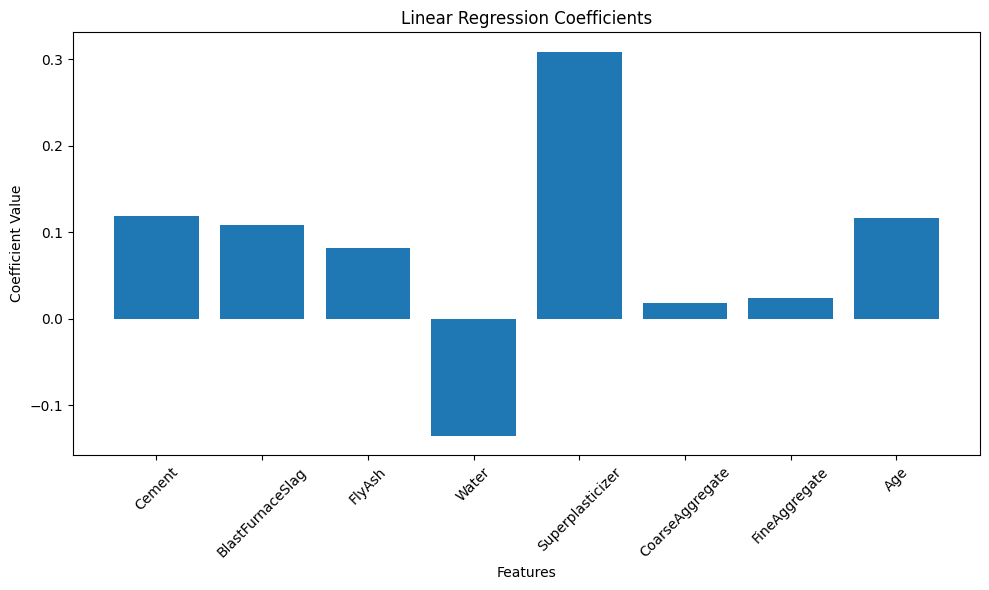

In [8]:
# Get the coefficients and their corresponding features
coefficients = lr.coef_
features = X.columns

# Plotting the coefficients
plt.figure(figsize=(10, 6))
plt.bar(features, coefficients)
plt.xticks(rotation=45)
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.title('Linear Regression Coefficients')
plt.tight_layout()
plt.show()


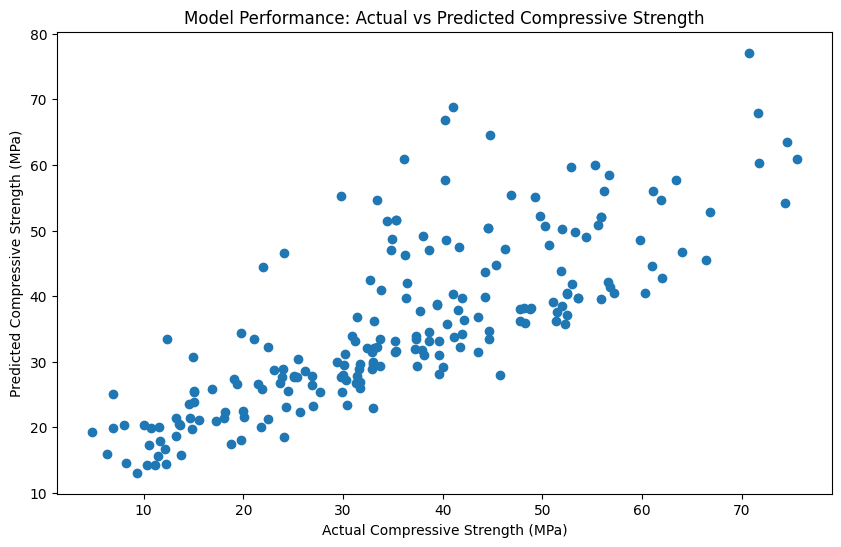

In [9]:
# Plot predicted vs actual values in the test set
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Compressive Strength (MPa)')
plt.ylabel('Predicted Compressive Strength (MPa)')
plt.title('Model Performance: Actual vs Predicted Compressive Strength')
plt.show()


## Assessing Projected Strength for Candidate Mixtures

The table below lists five candidate mixtures to evaluate with the trained model.

| Cement | BlastFurnaceSlag | FlyAsh | CoarseAggregate | FineAggregate | Water | Superplasticizer | Age |
|---|---|---|---|---|---|---|---|
| 175.0 | 13.0 | 172.0 | 1000.0 | 856.0 | 156.0 | 4.0 | 3 |
| 320.0 | 0.0 | 0.0 | 970.0 | 850.0 | 192.0 | 0.0 | 7 |
| 320.0 | 0.0 | 126.0 | 860.0 | 856.0 | 209.0 | 5.70 | 28 |
| 320.0 | 73.0 | 54.0 | 972.0 | 773.0 | 181.0 | 6.0 | 45 |
| 530.0 | 359.0 | 200.0 | 1145.0 | 992.0 | 247.0 | 32.0 | 365 |


In [10]:
candidate_mixtures = pd.DataFrame({
    'Cement': [175.0, 320.0, 320.0, 320.0, 530.0],
    'BlastFurnaceSlag': [13.0, 0.0, 0.0, 73.0, 359.0],
    'FlyAsh': [172.0, 0.0, 126.0, 54.0, 200.0],
    'Water': [156.0, 192.0, 209.0, 181.0, 247.0],
    'Superplasticizer': [4.0, 0.0, 5.70, 6.0, 32.0],
    'CoarseAggregate': [1000.0, 970.0, 860.0, 972.0, 1145.0],
    'FineAggregate': [856.0, 850.0, 856.0, 773.0, 992.0],
    'Age': [3, 7, 28, 45, 365],
})

# reorder to match training feature order
candidate_mixtures = candidate_mixtures[X.columns]
candidate_mixtures['PredictedStrength_MPa'] = lr.predict(candidate_mixtures).round(2)
candidate_mixtures


,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,PredictedStrength_MPa
0,175.0,13.0,172.0,156.0,4.0,1000.0,856.0,3,26.54
1,320.0,0.0,0.0,192.0,0.0,970.0,850.0,7,21.92
2,320.0,0.0,126.0,209.0,5.7,860.0,856.0,28,32.35
3,320.0,73.0,54.0,181.0,6.0,972.0,773.0,45,40.23
4,530.0,359.0,200.0,247.0,32.0,1145.0,992.0,365,152.93


**Note on the 365-day mixture:** the model predicts an unrealistically high strength (over 150 MPa) for the last candidate mixture. That mixture combines a high cement content with an age of 365 days, a region of the feature space the training data barely covers (the training data tops out around 82 MPa). Linear regression does not know it is extrapolating, so it keeps extending the same linear trend past the range it was fit on. In practice this prediction should not be trusted; a non-linear model (e.g. random forest or gradient boosting), or simply capping predictions at the observed strength range, would guard against this.

## Prediction Interface

A small helper function collects a mixture from the user and returns the model's strength
estimate.

In [11]:
# Defining function for strength prediction
def predict_user_input(model):
    print("Please enter the following information:")
    Cement = float(input("Amount of Cement in Mixture: "))
    BlastFurnaceSlag = float(input("Amount of Blast Furnace Slag in Mixture: "))
    FlyAsh = float(input("Amount of Fly Ash in Mixture: "))
    Water = float(input("Amount of Water in Mixture: "))
    Superplasticizer = float(input("Amount of Superplasticizer in Mixture: "))
    CoarseAggregate = float(input("Amount of Coarse Aggregate in Mixture: "))
    FineAggregate = float(input("Amount of Fine Aggregate in Mixture: "))
    Age = float(input("Age of Sample (in days): "))

    # Create a DataFrame with the user input
    user_data = pd.DataFrame({
        'Cement': [Cement],
        'BlastFurnaceSlag': [BlastFurnaceSlag],
        'FlyAsh': [FlyAsh],
        'Water': [Water],
        'Superplasticizer': [Superplasticizer],
        'CoarseAggregate': [CoarseAggregate],
        'FineAggregate': [FineAggregate],
        'Age': [Age]
    })

    # Predict concrete strength using the model
    prediction = model.predict(user_data)
    print("\nThe predicted concrete strength for the given input is:", round(prediction[0], 2), "MPa")
    return prediction[0]


Rerun the cell below to make a prediction interactively.

In [12]:
# predict_user_input(lr)


## Updating the Model with New Data

This function appends new observations to the dataset and retrains the model, so the model
can improve as more real-world results come in.

In [13]:
# Function to add new data to the model
def add_new_data(model, existing_data, filename, column_mapper=None):
    # Read new data from the file
    new_data = pd.read_excel(filename)

    # Rename columns if needed (pass a dict mapping source column names to the
    # standard names used in this notebook)
    if column_mapper:
        new_data = new_data.rename(columns=column_mapper)

    # Concatenate existing data with new data
    combined_data = pd.concat([existing_data, new_data], ignore_index=True)

    new_X = combined_data.drop(columns=['CC_Strength'])
    new_y = combined_data['CC_Strength']

    # Split the combined data into training and testing sets
    new_X_train, new_X_test, new_y_train, new_y_test = train_test_split(
        new_X, new_y, test_size=0.2, random_state=42)

    # Build and train the linear regression model
    model.fit(new_X_train, new_y_train)

    print("Model retrained with new data successfully.")
    return model, combined_data


In [14]:
# Example usage:
# new_lr, new_combined_data = add_new_data(lr, data, "data/new_data_file.xlsx")


## Conclusion

A linear regression model trained on the eight mixture features predicts compressive
strength with an R-squared of about 0.57 on held-out data. Water content and superplasticizer
dose show the strongest linear relationships with strength, which lines up with the
literature: water-cement ratio is a well known driver of concrete strength. A linear model is
a reasonable baseline, but the scatter plots show non-linear relationships for several
features (notably Age), so a tree-based or non-linear model would likely improve on this
result in future work.
